# Project 2 — Data Classification Using AI
### DecodeLabs Industrial Training Kit | Batch 2026

**Goal:** Build a basic classification model using a small dataset (Iris).

**Pipeline (IPO Framework):**
- **Input:** Iris dataset, feature scaling
- **Process:** Train-test split, KNN algorithm, tuning K
- **Output:** Confusion matrix, F1 score

**Key skills demonstrated:** data handling, supervised learning basics, model training.


## 1. Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score, f1_score
)

sns.set_style("whitegrid")
np.random.seed(42)


## 2. Load and Understand the Dataset — "Raw Material: The Iris Benchmark"

- **Samples:** 150 (balanced, 50 per class)
- **Classes:** 3 (Setosa, Versicolor, Virginica)
- **Dimensions/Features:** 4 (sepal length, sepal width, petal length, petal width)


In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y, target_names)

print("Shape:", df.shape)
print("Classes:", target_names)
df.head()


Shape: (150, 5)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Quick class balance check
df['species'].value_counts()


,count
species,
setosa,50
versicolor,50
virginica,50


In [4]:
# Statistical summary
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Visualize the data

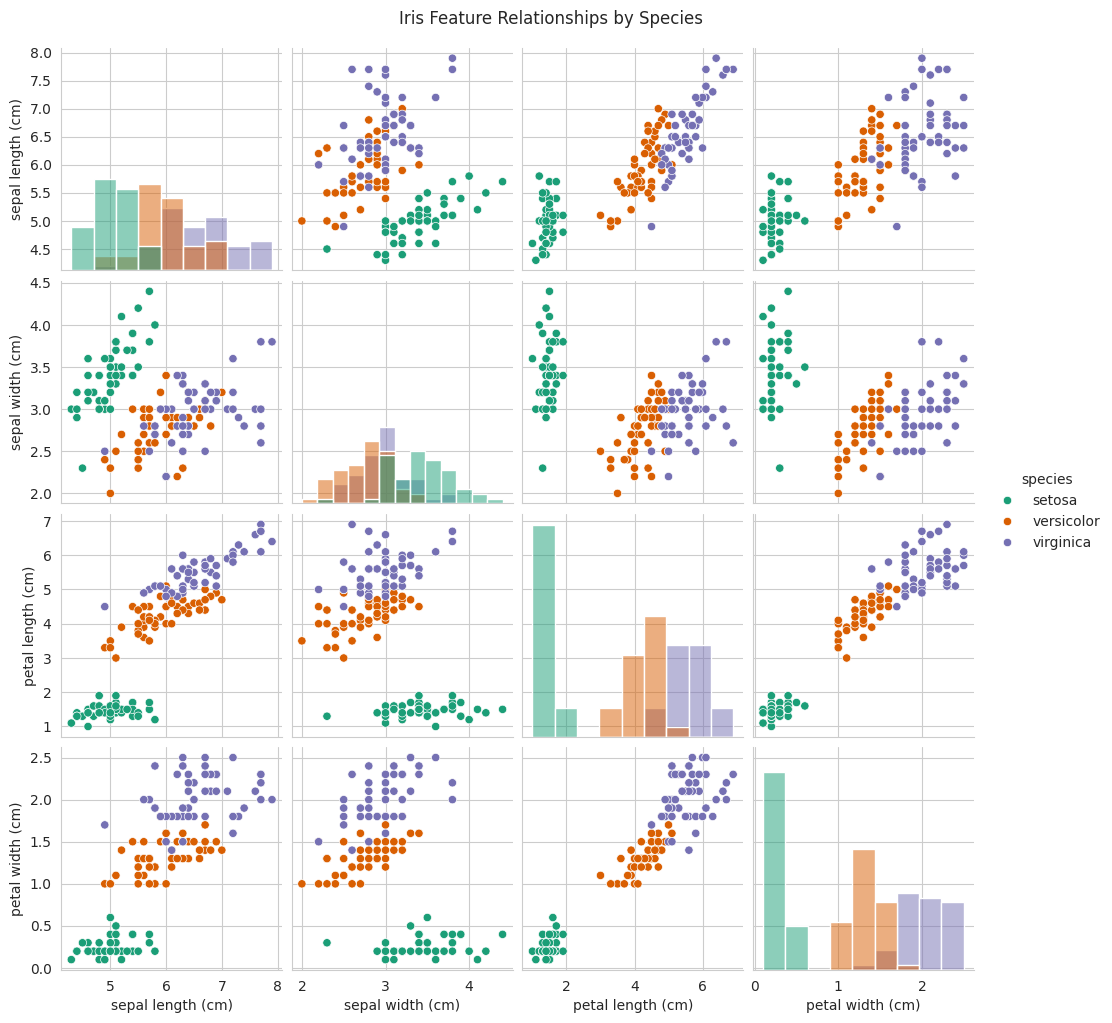

In [5]:
sns.pairplot(df, hue='species', diag_kind='hist', palette='Dark2')
plt.suptitle("Iris Feature Relationships by Species", y=1.02)
plt.show()


## 3. The Gatekeeper Rule: Feature Scaling

KNN is a distance-based algorithm, so features on larger numeric ranges would
dominate the distance calculation unless we scale everything to the same
range. We use `StandardScaler` (mean = 0, variance = 1).

**Important:** we fit the scaler on the training data only, then use it to
transform the test data — this avoids "leaking" information from the test
set into training.


## 4. Structural Integrity: The Train-Test Split

We shuffle and split the data so the model is trained on one portion and
validated on a completely unseen portion.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train / 20% test
    random_state=42,
    stratify=y          # keep class balance in both splits
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)         # transform only on test


Training samples: 120
Testing samples: 30


## 5. Tuning the Engine: Choosing "K"

- Small K (e.g. K=1) → sensitive to noise, risk of overfitting.
- Large K (e.g. K=100) → overly generic, risk of underfitting.
- We scan a range of K values and pick the "elbow" — the point of lowest
  error rate on the test set.


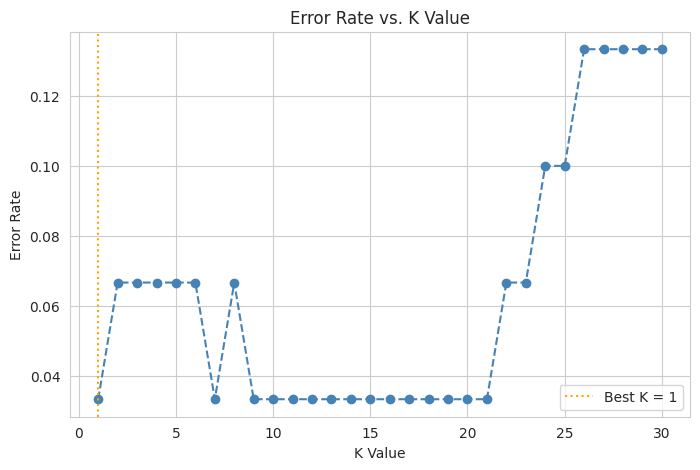

Optimal K selected: 1


In [7]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    preds_temp = knn_temp.predict(X_test_scaled)
    error_rates.append(np.mean(preds_temp != y_test))

plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='--', color='steelblue')
plt.title("Error Rate vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
best_k = k_range[int(np.argmin(error_rates))]
plt.axvline(best_k, color='orange', linestyle=':', label=f"Best K = {best_k}")
plt.legend()
plt.show()

print(f"Optimal K selected: {best_k}")


## 6. The Workflow: scikit-learn (Instantiate → Fit → Predict)


In [8]:
model = KNeighborsClassifier(n_neighbors=best_k)   # INSTANTIATE
model.fit(X_train_scaled, y_train)                 # FIT (memorize the map)
predictions = model.predict(X_test_scaled)         # PREDICT (apply logic)

print("Predictions: ", predictions)
print("Actual:      ", y_test)


Predictions:  [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 1 1 0 2 0]
Actual:       [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## 7. Output Validation — Beyond the "Accuracy Mirage"

On imbalanced datasets, raw accuracy can be misleading. We look deeper using
a **confusion matrix**, **precision/recall**, and the **F1 score** (the
harmonic mean of precision and recall).


In [9]:
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=target_names))


Accuracy: 0.9667
Weighted F1 Score: 0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — KNN on Iris Test Set")
plt.show()


## 8. Try It Yourself — Predict on a New Flower Measurement

Feel free to change the values below to test the model on your own
made-up flower measurements.


In [ ]:
# Format: [sepal_length, sepal_width, petal_length, petal_width] in cm
new_sample = np.array([[5.8, 3.0, 4.2, 1.2]])
new_sample_scaled = scaler.transform(new_sample)

pred_class = model.predict(new_sample_scaled)[0]
pred_proba = model.predict_proba(new_sample_scaled)[0]

print(f"Predicted species: {target_names[pred_class]}")
for name, proba in zip(target_names, pred_proba):
    print(f"  {name}: {proba*100:.1f}%")


## 9. Conclusion

This notebook walked through the full **Input → Process → Output** pipeline
for a classification task:

1. Loaded and explored the Iris dataset.
2. Scaled features with `StandardScaler`.
3. Split data into training and test sets (with stratification).
4. Tuned the K hyperparameter using an error-rate curve.
5. Trained a K-Nearest Neighbors classifier.
6. Validated the model using accuracy, F1 score, and a confusion matrix.

**Next steps:** try swapping in another small dataset (e.g. Wine or Breast
Cancer from `sklearn.datasets`), or compare KNN against another simple
classifier like Logistic Regression or Decision Tree, to build a more
well-rounded understanding of supervised learning before moving on to
neural networks.

*Project 2 — DecodeLabs Industrial Training Kit, Batch 2026*
